<a href="https://colab.research.google.com/github/Ishini01/AdvancedImageEditor/blob/main/Implemetation_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Kaggle API & Setup

In [7]:
# Create kaggle folder
!mkdir -p ~/.kaggle

# Copy kaggle.json (upload your API key first)
!cp kaggle.json ~/.kaggle/

# Set permission
!chmod 600 ~/.kaggle/kaggle.json

Download Dataset From Kaggle

In [8]:
!kaggle datasets download -d ahilaprem/mepco-tropic-leaf

Dataset URL: https://www.kaggle.com/datasets/ahilaprem/mepco-tropic-leaf
License(s): unknown
100% 2.98G/2.99G [00:46<00:00, 158MB/s]
100% 2.99G/2.99G [00:46<00:00, 68.3MB/s]


Unzip Dataset

In [9]:
!unzip -q mepco-tropic-leaf.zip

In [30]:
import os
import zipfile
import shutil

# Paths for extracted datasets
dataset_path1 = "/content/MepcoTropicLeaf-V1/Database"
dataset_path2 = "/content/Spinach/Database"

# Function to extract all zip files from source to target folder
def extract_dataset(source_dir, target_dir):
    os.makedirs(target_dir, exist_ok=True)
    for root, dirs, files in os.walk(source_dir):
        for file in files:
            if file.endswith(".zip") and file != "mepco-tropic-leaf.zip":
                class_name = file.replace(".zip","")
                extract_path = os.path.join(target_dir,class_name)
                os.makedirs(extract_path,exist_ok=True)
                zip_path = os.path.join(root,file)
                try:
                    with zipfile.ZipFile(zip_path,"r") as zip_ref:
                        zip_ref.extractall(extract_path)
                except:
                    pass

# Extract datasets
extract_dataset(".", dataset_path1)
extract_dataset(".", dataset_path2)

print("Both datasets prepared successfully")

Both datasets prepared successfully


In [33]:
import os
import shutil

# Merge dataset2 into dataset1 safely
for class_name in os.listdir(dataset_path2):
    src = os.path.join(dataset_path2, class_name)
    dst = os.path.join(dataset_path1, class_name)
    os.makedirs(dst, exist_ok=True)

    # Loop through items in src
    for item in os.listdir(src):
        src_item = os.path.join(src, item)

        # Only copy if it's a file
        if os.path.isfile(src_item):
            shutil.copy(src_item, dst)

# Final merged dataset path
dataset_path = dataset_path1
print("Datasets merged into:", dataset_path)

Datasets merged into: /content/MepcoTropicLeaf-V1/Database


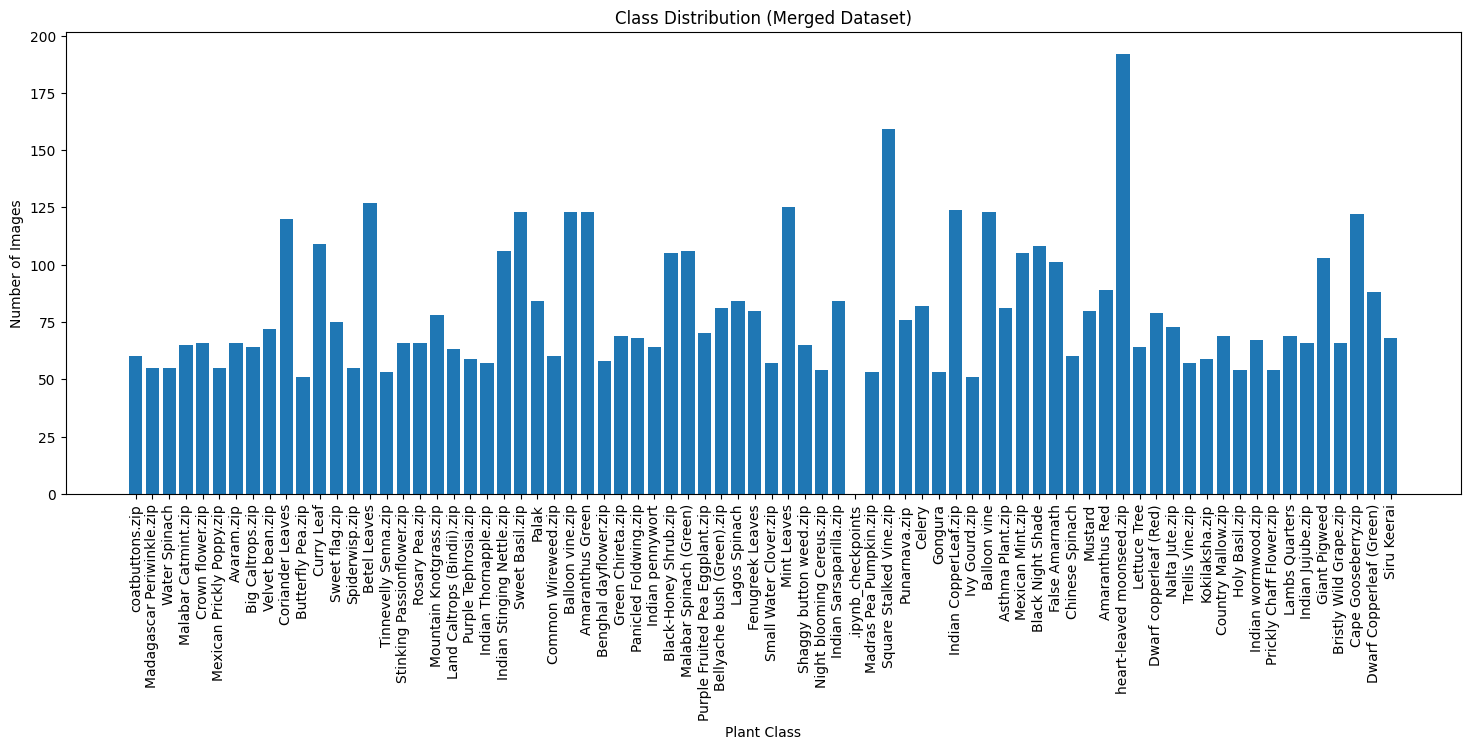

In [37]:
import matplotlib.pyplot as plt

class_counts = {}
for class_name in os.listdir(dataset_path):
    class_dir = os.path.join(dataset_path,class_name)
    if os.path.isdir(class_dir):
        class_counts[class_name] = len(os.listdir(class_dir))

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(18,6))
plt.bar(classes,counts)
plt.xticks(rotation=90)
plt.title("Class Distribution (Merged Dataset)")
plt.xlabel("Plant Class")
plt.ylabel("Number of Images")
plt.show()

Found 6021 files belonging to 75 classes.
Using 4817 files for training.


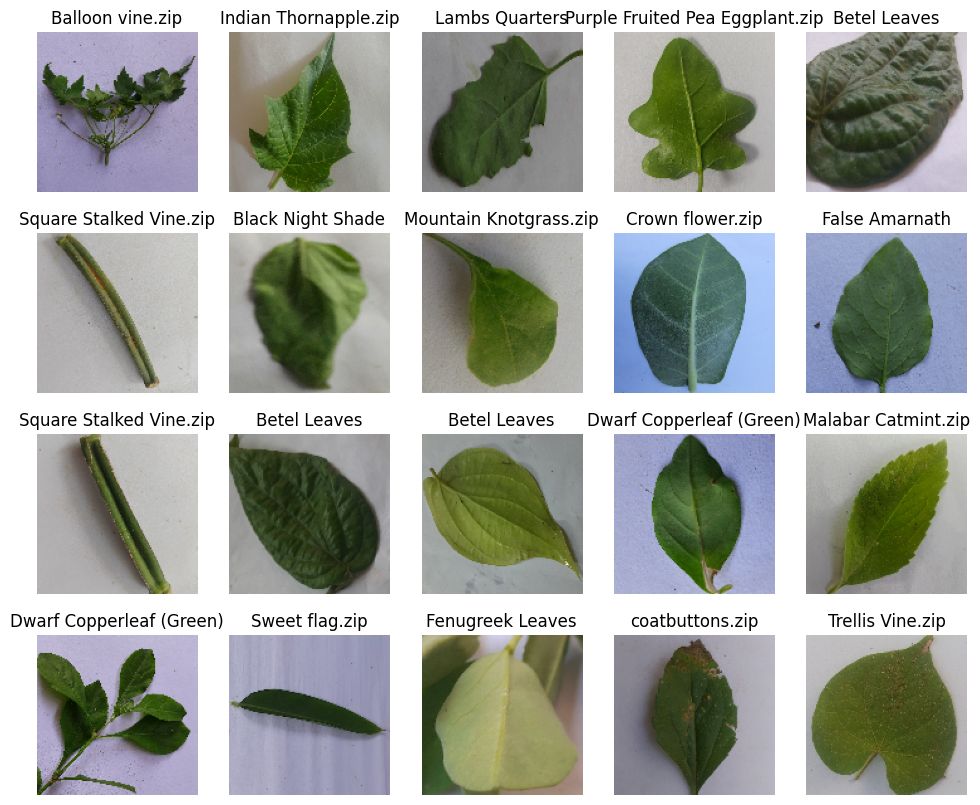

In [38]:
import tensorflow as tf

batch_size = 32
img_height = 128
img_width = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height,img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names

plt.figure(figsize=(12,10))
for images,labels in train_ds.take(1):
    for i in range(20):
        plt.subplot(4,5,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [39]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 4848 images belonging to 76 classes.
Found 1173 images belonging to 76 classes.


In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

num_classes = train_generator.num_classes

model = Sequential([
    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(128,128,3)),
    BatchNormalization(),
    Conv2D(32,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    Conv2D(64,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    Conv2D(128,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(256,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    Conv2D(256,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Flatten(),
    Dense(512,activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(num_classes,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,606,252 (36.64 MB)

 Trainable params: 9,603,308 (36.63 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [42]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=validation_generator,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1084 - loss: 4.1162